# Mi loco estamos crazy
## real


In [15]:
import mne
from mne.decoding import CSP
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier 
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier

from pyriemann.estimation import Covariances
from pyriemann.classification import MDM

from sklearn.model_selection import ShuffleSplit, cross_val_score, cross_validate, train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

In [16]:
def balance_clases(x_train, y_train):
    classes, counts = np.unique(y_train, return_counts=True)
    min_count = counts.min()

    indices = []

    for c in classes:
        class_idx = np.where(y_train == c)[0]
        sampled_idx = np.random.choice(class_idx, min_count, replace=False)
        indices.extend(sampled_idx)

    indices = np.array(indices)

    x_bal = x_train[indices]
    y_bal = y_train[indices]

    shuffle_idx = np.random.permutation(len(y_bal))

    x_train_balanced = x_bal[shuffle_idx]
    y_train_balanced = y_bal[shuffle_idx]
    return  x_train_balanced, y_train_balanced

def fourier(x_algo):

    sfreq = 250
    fmin, fmax = 8, 30
    n_windows, n_channels, n_samples = x_algo.shape
    freqs = np.fft.rfftfreq(n_samples, 1/sfreq)
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    
    # FFT por ventana y canal
    X_fft = np.abs(np.fft.rfft(x_algo, axis=2))[:, :, band_mask]**2
    X_fft = np.log(X_fft + 1e-12)
    
    # Aplanar para clasificador
    x_cambio = X_fft.reshape(n_windows, -1)
    
    return x_cambio

In [17]:
def get_models():

    models = {

        "svm": {
            "model": SVC(),
            "params": {
                "clf__C": [0.1, 1, 10],
                "clf__kernel": ["linear", "rbf"]
            }
        },

        "lda": {
            "model": LinearDiscriminantAnalysis(),
            "params": {
                "clf__solver": ["svd", "lsqr"]
            }
        },

        "logreg": {
            "model": LogisticRegression(max_iter=2000),
            "params": {
                "clf__C": [0.1, 1, 10]
            }
        },

        "rf": {
            "model": RandomForestClassifier(),
            "params": {
                "clf__n_estimators": [100,200],
                "clf__max_depth": [5,10]
            }
        },
        "rc": {
            "model": MDM(metric="riemann"),
            "params": {
                "clf__metric": ["riemann"],
            }
        }

    }

    return models


# ======================
# FEATURES
# ======================

def get_feature_pipelines():

    features = {

        "basic": [],

        "scaled": [
            ("scaler", StandardScaler())
        ],

        "csp": [
            ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False))
        ],
        "covariance": [
            ("covariance", Covariances())
        ]

    }

    return features


# ======================
# CLASIFICADOR JERARQUICO
# ======================

def train_hierarchical(X, y, pipeline, param_grid, cv):

    # reposo vs movimiento
    y_01 = (y != 0).astype(int)
    
    X_01_bal, y_01_bal = balance_clases(X, y_01)
    print("Shape:", X_01_bal.shape, y_01_bal.shape)

    grid_lvl1 = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_lvl1.fit(X_01_bal, y_01_bal)


    # movimiento1 vs movimiento2
    mask = y != 0

    X_12 = X[mask]
    y_12 = y[mask] - 1


    X_12_bal, y_12_bal = balance_clases(X_12, y_12)
    print("Shape:", X_12_bal.shape, y_12_bal.shape)

    grid_lvl2 = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_lvl2.fit(X_12_bal, y_12_bal)

    return grid_lvl1, grid_lvl2


def hierarchical_predict(X, model1, model2):

    pred_lvl1 = model1.predict(X)

    final_pred = np.zeros(len(X))

    move_idx = np.where(pred_lvl1 == 1)[0]

    if len(move_idx) > 0:

        pred_lvl2 = model2.predict(X[move_idx])

        final_pred[move_idx] = pred_lvl2 + 1

    return final_pred


Shape: (5241, 8, 375) (5241,)

Features disponibles:
- basic
- scaled
- csp
- covariance


Selecciona features (coma):  covariance



Modelos disponibles:
- svm
- lda
- logreg
- rf
- rc


Selecciona modelos (coma):  rc



Probando covariance + rc
Shape: (1722, 8, 375) (1722,)
Shape: (860, 8, 375) (860,)

===== RESULTADOS =====
covariance + rc | reposo/mov=0.571 | mov1/mov2=0.550


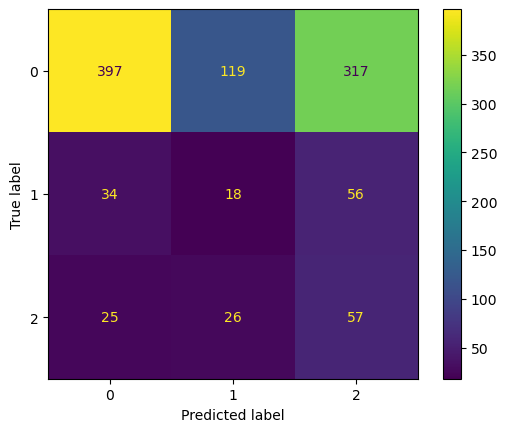

In [18]:
# ======================
# CARGAR DATOS Y DIVIDIR
# ======================

data = np.load("datos_procesados.npz")

X = data["x"]
y = data["y"]

print("Shape:", X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,   # 20% para validación
    stratify=y,      # misma distribución de clases en tanto en train como test 
    random_state=36  # para reproducibilidad
)

# ======================
# SELECCION INTERACTIVA
# ======================

features = get_feature_pipelines()
models = get_models()

print("\nFeatures disponibles:")
for f in features:
    print("-", f)

features_input = input("Selecciona features (coma): ")
selected_features = [f.strip() for f in features_input.split(",")]


print("\nModelos disponibles:")
for m in models:
    print("-", m)

models_input = input("Selecciona modelos (coma): ")
selected_models = [m.strip() for m in models_input.split(",")]


# ======================
# EXPERIMENTOS
# ======================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

results = []

for feat_name in selected_features:

    if feat_name not in features:
        continue

    feature_steps = features[feat_name]

    for model_name in selected_models:

        if model_name not in models:
            continue

        model = models[model_name]["model"]

        param_grid = models[model_name]["params"].copy()


        pipeline = Pipeline(
            feature_steps + [("clf", model)]
        )


        print(f"\nProbando {feat_name} + {model_name}")


        model1, model2 = train_hierarchical(
            X_train,
            y_train,
            pipeline,
            param_grid,
            cv
        )


        score = model1.best_score_

        results.append({

            "feature": feat_name,
            "model": model_name,
            "score_lvl1": model1.best_score_,
            "score_lvl2": model2.best_score_,
            "params1": model1.best_params_,
            "params2": model2.best_params_

        })


# ======================
# RESULTADOS
# ======================

print("\n===== RESULTADOS =====")

results = sorted(
    results,
    key=lambda x: x["score_lvl1"],
    reverse=True
)

for r in results:

    print(
        f"{r['feature']} + {r['model']} | "
        f"reposo/mov={r['score_lvl1']:.3f} | "
        f"mov1/mov2={r['score_lvl2']:.3f}"
    )

y_pred = hierarchical_predict(X_test, model1.best_estimator_, model2.best_estimator_)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [40]:
def basic_features(x, y):
    return x

def csp_features(x, y):
    csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
    return csp.fit_transform(x, y)

def pca_features(x, y, n_components=10):
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    
    pca = PCA(n_components=n_components)
    return pca.fit_transform(x_scaled)

def get_models():

    models = {

        "svm": {
            "model": SVC(),
            "params": {
                "clf__C": [0.1, 1, 10, 100],
                "clf__kernel": ["linear", "rbf"]
            }
        },

        "random_forest": {
            "model": RandomForestClassifier(random_state=29),
            "params": {
                "clf__n_estimators": [100, 200, 400],
                "clf__max_depth": [5, 10, 20]
            }
        },

        "lda": {
            "model": LinearDiscriminantAnalysis(),
            "params": {
                "clf__solver": ["svd", "lsqr"]
            }
        },

        "logistic_regression": {
            "model": LogisticRegression(max_iter=1000),
            "params": {
                "clf__C": [0.1, 1, 10, 100]
            }
        }

    }

    return models

In [41]:
#main
data = np.load("datos_procesados.npz")

x = data["x"]
y = data["y"]

print(x.shape, y.shape)

#x_train, y_train = balance_clases (x_train, y_train)
#x_test, y_test = balance_clases (x_test, y_test)

#x_train, x_test, y_train, y_test = train_test_split(
#    x, 
#    y,
#    test_size=0.2,   # 20% para validación
#    stratify=y,      # misma distribución de clases en tanto en train como test 
#    random_state=36  # para reproducibilidad
#)

feature_methods = {
"basic": basic_features,
"csp": csp_features,
"pca": lambda x_train: pca_features(x_train, n_components=10)
}

models = get_models()

print("Features disponibles:")
for name in feature_methods:
    print("-", name)

features_input = input("Introduce las features a usar (separadas por coma): ")
selected_feature_names = [f.strip() for f in features_input.split(",")]

selected_features = {
    k: v for k, v in feature_methods.items()
    if k in selected_feature_names
}

print("\nModelos disponibles:")
for name in models:
    print("-", name)

models_input = input("Introduce los modelos a usar (separados por coma): ")
selected_model_names = [m.strip() for m in models_input.split(",")]

selected_models = {
    k: v for k, v in models.items()
    if k in selected_model_names
}

if not selected_features:
    raise ValueError("No se seleccionó ninguna feature válida")

if not selected_models:
    raise ValueError("No se seleccionó ningún modelo válido")

best_score = 0
best_config = None

type_training=int(input("Quieres entrenar manera simple (1), manera Gonzalo (2), o manera Robert (3)? Dime: "))

if type_training==1:
    for model in models:
            
        clf = Pipeline([
            ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
            ("model", model)
        ])
    
        clf.fit(x_train, y_train)
    
        print(model)
        print("Accuracy:", clf.score(x_test, y_test))
    
        y_pred = clf.predict(x_test)
    
        cm = confusion_matrix(y_test, y_pred)
        print("Matriz de confusión:\n", cm)
    
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()

elif type_training==2:
    for model in models:
        pipe = Pipeline([
            ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
            ("model", model)])
        clf=OneVsRestClassifier(pipe)
        clf.fit(x_train, y_train)
        print(model)
        print(clf.score(x_test , y_test))

        y_pred = clf.predict(x_test)
        cm = confusion_matrix(y_test, y_pred)
        print("Matriz de confusión:\n", cm)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()

elif type_training==3:

    y_bin = (y != 0).astype(int)
    x_train, y_bin_train = balance_clases (x, y_bin)

    for feat_name, feat_func in selected_features.items():

        x_feat = feat_func(x_train, y_bin_train)

        for model_name, config in selected_models.items():
    
            grid = GridSearchCV(
                config["model"],
                config["params"],
                cv=5,
                scoring="accuracy"
            )
    
            grid.fit(x_feat, y_bin_train)
    
            score = grid.best_score_
    
            print(feat_name, model_name, score)
    
            if score > best_score:
                best_score = score
                best_config = (feat_name, model_name, grid.best_estimator_)

    print("Best:", best_config)

#    y_pred_rest = clf_reposo.predict(x_test)
 #   cm = confusion_matrix(y_bin_test, y_pred_rest)
  #  print("Matriz de confusión:\n", cm)
   # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    #disp.plot()

    
else:
    print("tendrías que haber dado 1, 2 o 3")

(5241, 8, 375) (5241,)
Features disponibles:
- basic
- csp
- pca


Introduce las features a usar (separadas por coma):  csp



Modelos disponibles:
- svm
- random_forest
- lda
- logistic_regression


Introduce los modelos a usar (separados por coma):  svm
Quieres entrenar manera simple (1), manera Gonzalo (2), o manera Robert (3)? Dime:  3


Computing rank from data with rank=None
    Using tolerance 15 (2.2e-16 eps * 8 dim * 8.6e+15  max singular value)
    Estimated rank (data): 8
    data: rank 8 computed from 8 data channels with 0 projectors
Reducing data rank from 8 -> 8
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


ValueError: Invalid parameter 'clf' for estimator SVC(). Valid parameters are: ['C', 'break_ties', 'cache_size', 'class_weight', 'coef0', 'decision_function_shape', 'degree', 'gamma', 'kernel', 'max_iter', 'probability', 'random_state', 'shrinking', 'tol', 'verbose'].